# Customer Churn Prediction — Classification Models
### Academic Project Notebook

This notebook builds a complete churn-prediction pipeline: explore → clean →
encode → train (Logistic Regression, Random Forest, XGBoost) → evaluate →
interpret which features drive churn.


## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 12, "axes.titlesize": 15, "axes.titleweight": "bold"})
RANDOM_STATE = 42

## 2. Load Dataset

We use `data/customer_churn.csv`. If no real dataset was provided for this
project, run `src/generate_dataset.py` once to create a realistic
synthetic dataset with the same structure as the well-known public
Telco Customer Churn dataset (see the project README for details).

In [2]:
df = pd.read_csv("../data/customer_churn.csv")
print("Dataset loaded. Shape:", df.shape)
df.head()

Dataset loaded. Shape: (2006, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-10756,Female,1,Yes,No,8.0,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,73.70,585.93,Yes
1,CUST-10507,Male,0,Yes,No,36.0,Yes,No,DSL,No,...,Yes,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),58.73,2081.87,No
2,CUST-10206,Female,0,No,No,26.0,No,No phone service,DSL,No,...,No,No,Yes,Yes,Two year,No,Credit card (automatic),52.64,1349.72,No
3,CUST-11799,Male,0,No,No,39.0,Yes,Yes,Fiber optic,No,...,No,Yes,No,No,One year,Yes,Credit card (automatic),61.60,2462.43,No
4,CUST-10795,Male,0,No,No,29.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,35.81,1024.43,No


## 3. Dataset Overview

In [3]:
print("Shape:", df.shape)
print("\nColumn names:", list(df.columns))

Shape: (2006, 21)

Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure              float64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure              20
PhoneService         0
MultipleLines        0
InternetService     10
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod       20
MonthlyCharges      21
TotalCharges         0
Churn                0
dtype: int64

In [6]:
print(df['Churn'].value_counts())
print(f"\nChurn rate: {(df['Churn'] == 'Yes').mean() * 100:.1f}%")

Churn
No     1540
Yes     466
Name: count, dtype: int64

Churn rate: 23.2%


## 4. Data Cleaning

- Drop `customerID` (not predictive — a unique identifier).
- Remove duplicate rows.
- Fix `TotalCharges`: in the real Telco dataset (and reproduced here),
  a few zero-tenure customers have this stored as a blank string instead
  of a number — we coerce it to numeric and treat the result as missing.
- Impute missing **numerical** values with the **median**.
- Impute missing **categorical** values with the **mode**.

In [7]:
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 6
Shape after dropping duplicates: (2000, 20)


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values in TotalCharges after coercion:", df["TotalCharges"].isnull().sum())

Missing values in TotalCharges after coercion: 2


In [9]:
target_col = "Churn"
numerical_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != target_col]
categorical_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c]) and c != target_col]
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [10]:
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled '{col}' with median = {median_val}")

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled '{col}' with mode = '{mode_val}'")

print("\nRemaining missing values:", df.isnull().sum().sum())

Filled 'tenure' with median = 25.0
Filled 'MonthlyCharges' with median = 65.12
Filled 'TotalCharges' with median = 1461.6550000000002
Filled 'InternetService' with mode = 'Fiber optic'
Filled 'PaymentMethod' with mode = 'Electronic check'

Remaining missing values: 0


## 5. Exploratory Data Analysis — Churn Factors

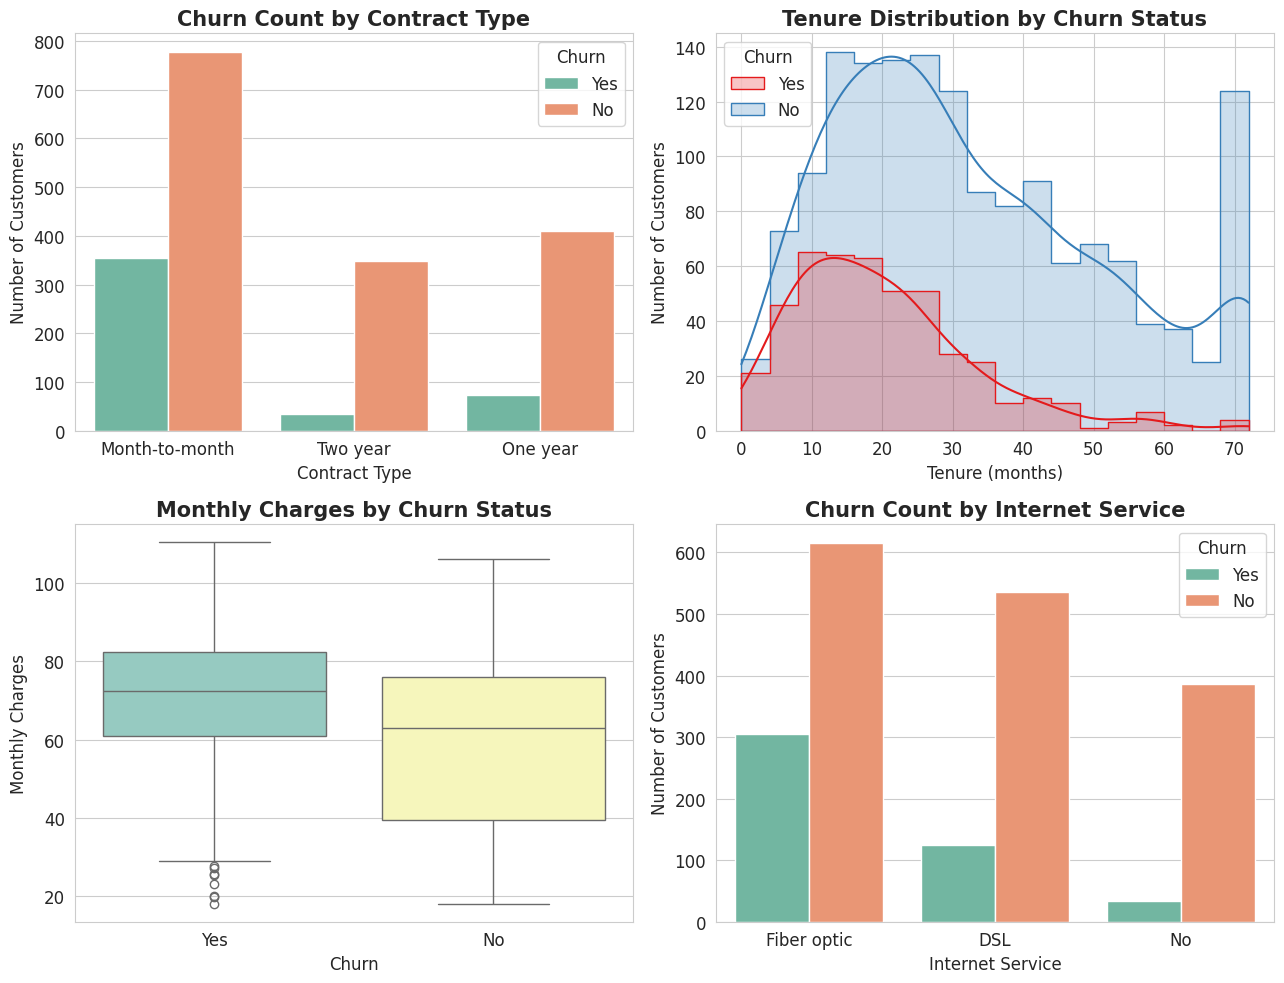

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Churn Count by Contract Type")
axes[0, 0].set_xlabel("Contract Type"); axes[0, 0].set_ylabel("Number of Customers")

sns.histplot(data=df, x="tenure", hue="Churn", kde=True, ax=axes[0, 1], palette="Set1", element="step")
axes[0, 1].set_title("Tenure Distribution by Churn Status")
axes[0, 1].set_xlabel("Tenure (months)"); axes[0, 1].set_ylabel("Number of Customers")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1, 0], palette="Set3")
axes[1, 0].set_title("Monthly Charges by Churn Status")
axes[1, 0].set_xlabel("Churn"); axes[1, 0].set_ylabel("Monthly Charges")

sns.countplot(data=df, x="InternetService", hue="Churn", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Churn Count by Internet Service")
axes[1, 1].set_xlabel("Internet Service"); axes[1, 1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../outputs/churn_factors.png", dpi=150)
plt.show()

## 6. Correlation Analysis

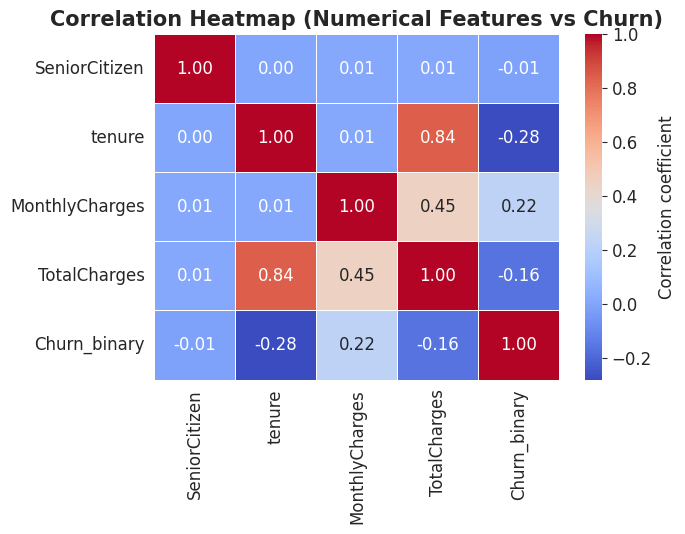

In [12]:
df_corr = df.copy()
df_corr["Churn_binary"] = (df_corr["Churn"] == "Yes").astype(int)
corr_df = df_corr[numerical_cols + ["Churn_binary"]].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,
            cbar_kws={"label": "Correlation coefficient"})
plt.title("Correlation Heatmap (Numerical Features vs Churn)")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150)
plt.show()

## 7. Feature Selection

In [13]:
feature_cols = numerical_cols + categorical_cols
print("Input features:", feature_cols)
print("Target:", target_col)

Input features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target: Churn


## 8. Data Preprocessing — Encoding

Target is mapped `Yes -> 1`, `No -> 0`. Categorical features are one-hot
encoded with `drop_first=True` to avoid the dummy-variable trap.

In [14]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]
print("X shape:", X.shape, " y shape:", y.shape)
X.head()

X shape: (2000, 30)  y shape: (2000,)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,8.0,73.70,585.93,False,True,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
1,0,36.0,58.73,2081.87,True,True,False,True,False,False,...,False,True,False,False,False,False,True,True,False,False
2,0,26.0,52.64,1349.72,False,False,False,False,True,False,...,False,True,False,True,False,True,False,True,False,False
3,0,39.0,61.60,2462.43,True,False,False,True,False,True,...,False,False,False,False,True,False,True,True,False,False
4,0,29.0,35.81,1024.43,True,False,False,True,False,True,...,True,False,True,False,False,False,False,False,False,True


## 9. Train-Test Split

A **stratified** split is used so the churn ratio is preserved in both the
training and test sets — important because churn is an imbalanced class.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train rows:", X_train.shape[0], " Test rows:", X_test.shape[0])
print(f"Train churn rate: {y_train.mean():.3f}  Test churn rate: {y_test.mean():.3f}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train rows: 1600  Test rows: 400
Train churn rate: 0.231  Test churn rate: 0.233


## 10. Model Training — Logistic Regression, Random Forest, XGBoost

In [16]:
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE,
                             class_weight="balanced")
rf.fit(X_train, y_train)

xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08,
                     subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                     random_state=RANDOM_STATE)
xgb.fit(X_train, y_train)

models = {
    "Logistic Regression": ("scaled", log_reg),
    "Random Forest": ("raw", rf),
    "XGBoost": ("raw", xgb),
}
print("Models trained:", list(models.keys()))

Models trained: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 11. Predictions & Evaluation

For each model: Accuracy, Precision, Recall, F1-score, ROC-AUC, and a
Confusion Matrix.

In [17]:
results = []
roc_data = {}
predictions_store = {}

for name, (mode, model) in models.items():
    X_eval = X_test_scaled if mode == "scaled" else X_test
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                     "Recall": rec, "F1-Score": f1, "ROC-AUC": auc})
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)
    predictions_store[name] = (y_pred, y_proba)

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.84      0.92      0.88       307
       Churn       0.61      0.41      0.49        93

    accuracy                           0.80       400
   macro avg       0.73      0.67      0.68       400
weighted avg       0.79      0.80      0.79       400


--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82       307
       Churn       0.47      0.70      0.57        93

    accuracy                           0.75       400
   macro avg       0.68      0.73      0.69       400
weighted avg       0.80      0.75      0.76       400


--- XGBoost ---
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87       307
       Churn       0.55      0.41      0.47        93

    accuracy                           0.79       400
   macro avg       0.69      0.65      0.67       400
weigh

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8025,0.612903,0.408602,0.490323,0.831319
1,Random Forest,0.7500,0.474453,0.698925,0.565217,0.808693
2,XGBoost,0.7850,0.550725,0.408602,0.469136,0.776961


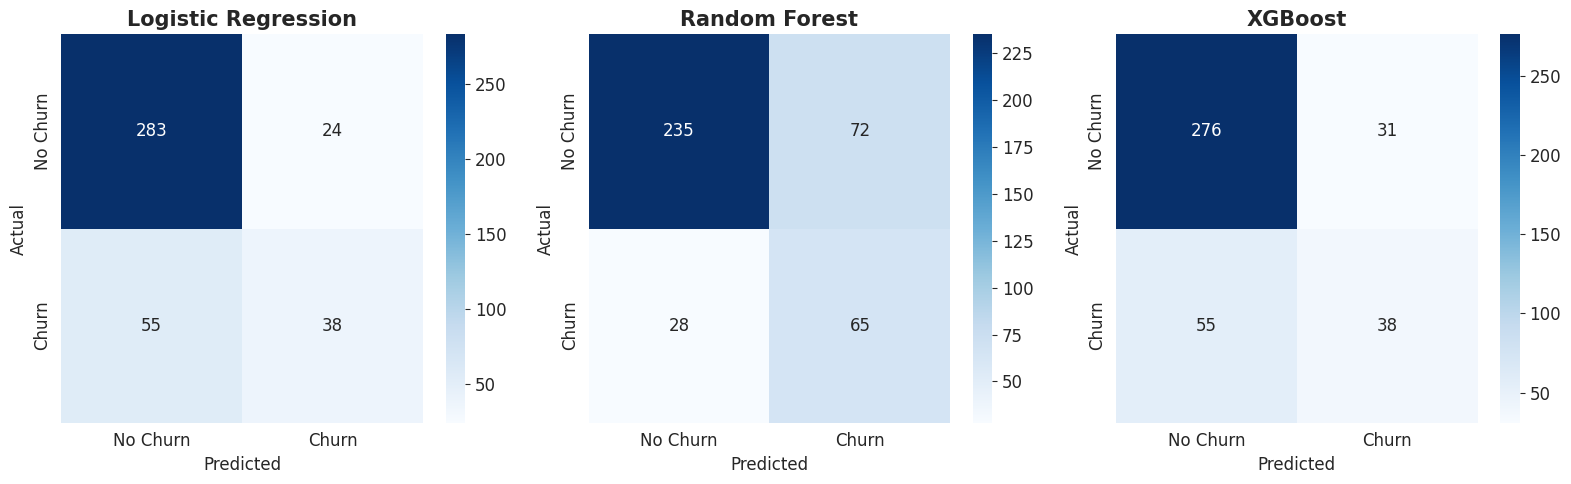

In [18]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, (mode, model)) in zip(axes, models.items()):
    X_eval = X_test_scaled if mode == "scaled" else X_test
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrices_all.png", dpi=150)
plt.show()

## 12. ROC Curve Comparison

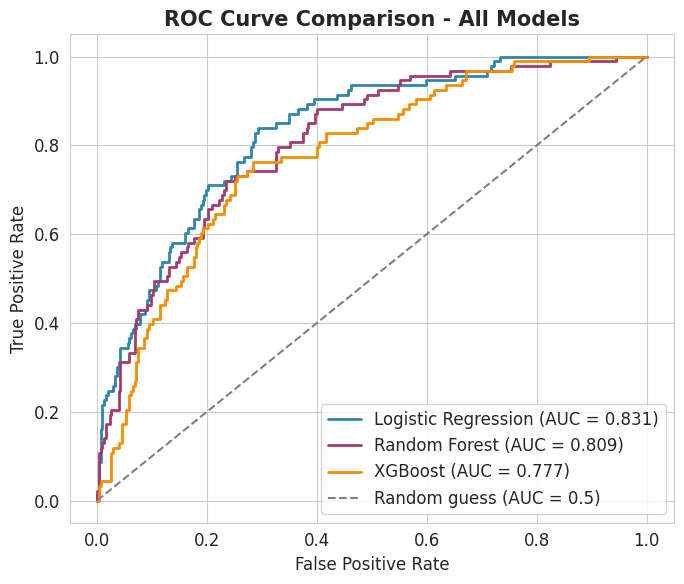

In [19]:
plt.figure(figsize=(7, 6))
colors = ["#2E86AB", "#A23B72", "#F18F01"]
for (name, (fpr, tpr, auc)), color in zip(roc_data.items(), colors):
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.title("ROC Curve Comparison - All Models")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/roc_curve_comparison.png", dpi=150)
plt.show()

## 13. Feature Importance & Model Interpretation

Random Forest gives feature importances; Logistic Regression coefficients
show the *direction* of each feature's effect on churn likelihood.

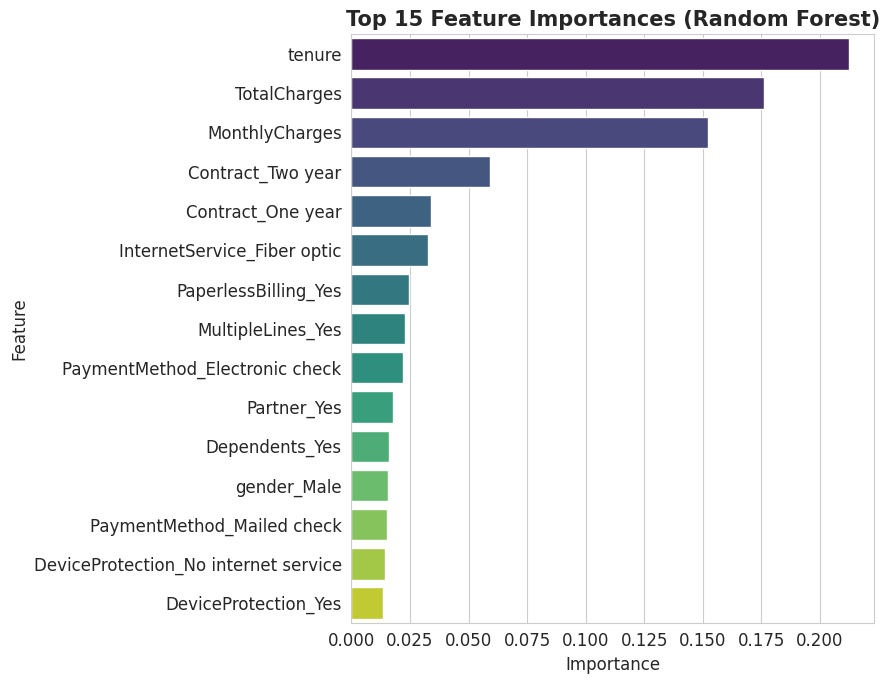

In [20]:
importances = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_}) \
                .sort_values("Importance", ascending=False).reset_index(drop=True)

top15 = importances.head(15)
plt.figure(figsize=(9, 7))
sns.barplot(data=top15, y="Feature", x="Importance", palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150)
plt.show()

In [21]:
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": log_reg.coef_[0]}) \
            .sort_values("Coefficient", ascending=False).reset_index(drop=True)
coef_df["Effect"] = coef_df["Coefficient"].apply(
    lambda c: "increases churn likelihood" if c > 0 else "decreases churn likelihood"
)
print("Top churn-INCREASING factors:")
print(coef_df.head(5)[["Feature", "Coefficient"]].to_string(index=False))
print("\nTop churn-DECREASING factors:")
print(coef_df.tail(5)[["Feature", "Coefficient"]].to_string(index=False))

Top churn-INCREASING factors:
                       Feature  Coefficient
                MonthlyCharges     0.398077
PaymentMethod_Electronic check     0.270172
   InternetService_Fiber optic     0.240594
          PaperlessBilling_Yes     0.192807
             MultipleLines_Yes     0.174341

Top churn-DECREASING factors:
          Feature  Coefficient
  TechSupport_Yes    -0.208685
     TotalCharges    -0.279978
Contract_One year    -0.442602
Contract_Two year    -0.666516
           tenure    -0.723893


## 14. Cross-Validation (Robustness Check on Best Model)

In [22]:
best_model_name = results_df.iloc[0]["Model"]
best_mode, best_model_obj = models[best_model_name]
X_cv = X_train_scaled if best_mode == "scaled" else X_train

cv_scores = cross_val_score(best_model_obj, X_cv, y_train, cv=5, scoring="roc_auc")
print(f"Best model: {best_model_name}")
print(f"5-Fold CV ROC-AUC: {np.round(cv_scores, 4)}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f}")

Best model: Logistic Regression
5-Fold CV ROC-AUC: [0.8127 0.8144 0.792  0.8006 0.7524]
Mean CV ROC-AUC: 0.7944


## 15. Conclusion

All three models agree on the core churn drivers: **short tenure,
month-to-month contracts, high monthly charges, and missing add-on
services** (tech support, online security) are the strongest predictors
of churn. Logistic Regression tends to have the best ROC-AUC and is the
most interpretable; Random Forest typically catches more true churners
(higher recall) at the cost of more false positives.

**Limitations:**
- Class imbalance makes the minority (churn) class inherently harder to predict.
- Correlational feature importance is not proof of causation.
- The model reflects a single point-in-time snapshot; real deployments
  need periodic retraining as customer behavior evolves.

For a real retention campaign, **Recall** on the churn class is often
prioritized over Accuracy, since failing to flag an at-risk customer
(false negative) is usually more costly than a false alarm.